In [1]:
import sys
import random
import argparse
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))

from ivsn_invariance import runtime, imaging, data

DATA_ROOT = Path('../dataset/coco_crops_transparent_8cat')
N_OBJECTS = 6
N_MATRIX = 3

args = argparse.Namespace(
    smoothing_mode='none',
    smooth_cue=False,
    smooth_target=False,
    smooth_distractors=False,
)

runtime.CATEGORIES = runtime.get_categories(N_OBJECTS)
dataset = data.load_dataset(DATA_ROOT)

all_paths = [p for cat in runtime.CATEGORIES for p in dataset[cat][:1]]
TARGET_PATH = all_paths[0]
DISTRACTOR_PATHS = all_paths[1:]

In [2]:
from ivsn_invariance.domain import TransformSpec


def draw_arrangement(ax, image, positions):
    ax.imshow(image)
    for x, y in positions:
        ax.plot(x, y, marker='+', color='lime', markersize=14, markeredgewidth=2)
        ax.add_patch(plt.Circle((x, y), runtime.OBJ_SIZE / 2, fill=False, edgecolor='blue', linewidth=1.5))
        ax.add_patch(plt.Circle((x, y), runtime.OBJ_SIZE / 2 + runtime.MAX_EPSILON, fill=False, edgecolor='red', linewidth=1.5, linestyle='--'))
    ax.set_xlim(0, runtime.IMAGE_SIZE)
    ax.set_ylim(runtime.IMAGE_SIZE, 0)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])


def render_background(padding, jitter, arrangement, n_matrix=N_MATRIX, n_objects=N_OBJECTS, seed=0, scale=1.0):
    if arrangement == 'circle':
        runtime.set_runtime_geometry_circle(n_objects, padding, jitter)
        n_distractors = n_objects - 1
    elif arrangement == 'grid':
        runtime.set_runtime_geometry_grid(n_matrix, padding, jitter)
        n_distractors = n_matrix ** 2 - 1
    else:
        raise ValueError(f'Unsupported arrangement: {arrangement}')

    target_position = 0
    distractor_paths = (DISTRACTOR_PATHS * n_distractors)[:n_distractors]
    target_transform = TransformSpec(scale=scale)
    distractor_transforms = [TransformSpec(scale=scale) for _ in distractor_paths]

    random.seed(seed)
    background = imaging.render_search_display(
        TARGET_PATH, distractor_paths, target_position,
        target_transform, distractor_transforms, args,
    )
    positions = runtime.POSITIONS
    return background, positions

## Cell 1: three padding values, jitter = 0

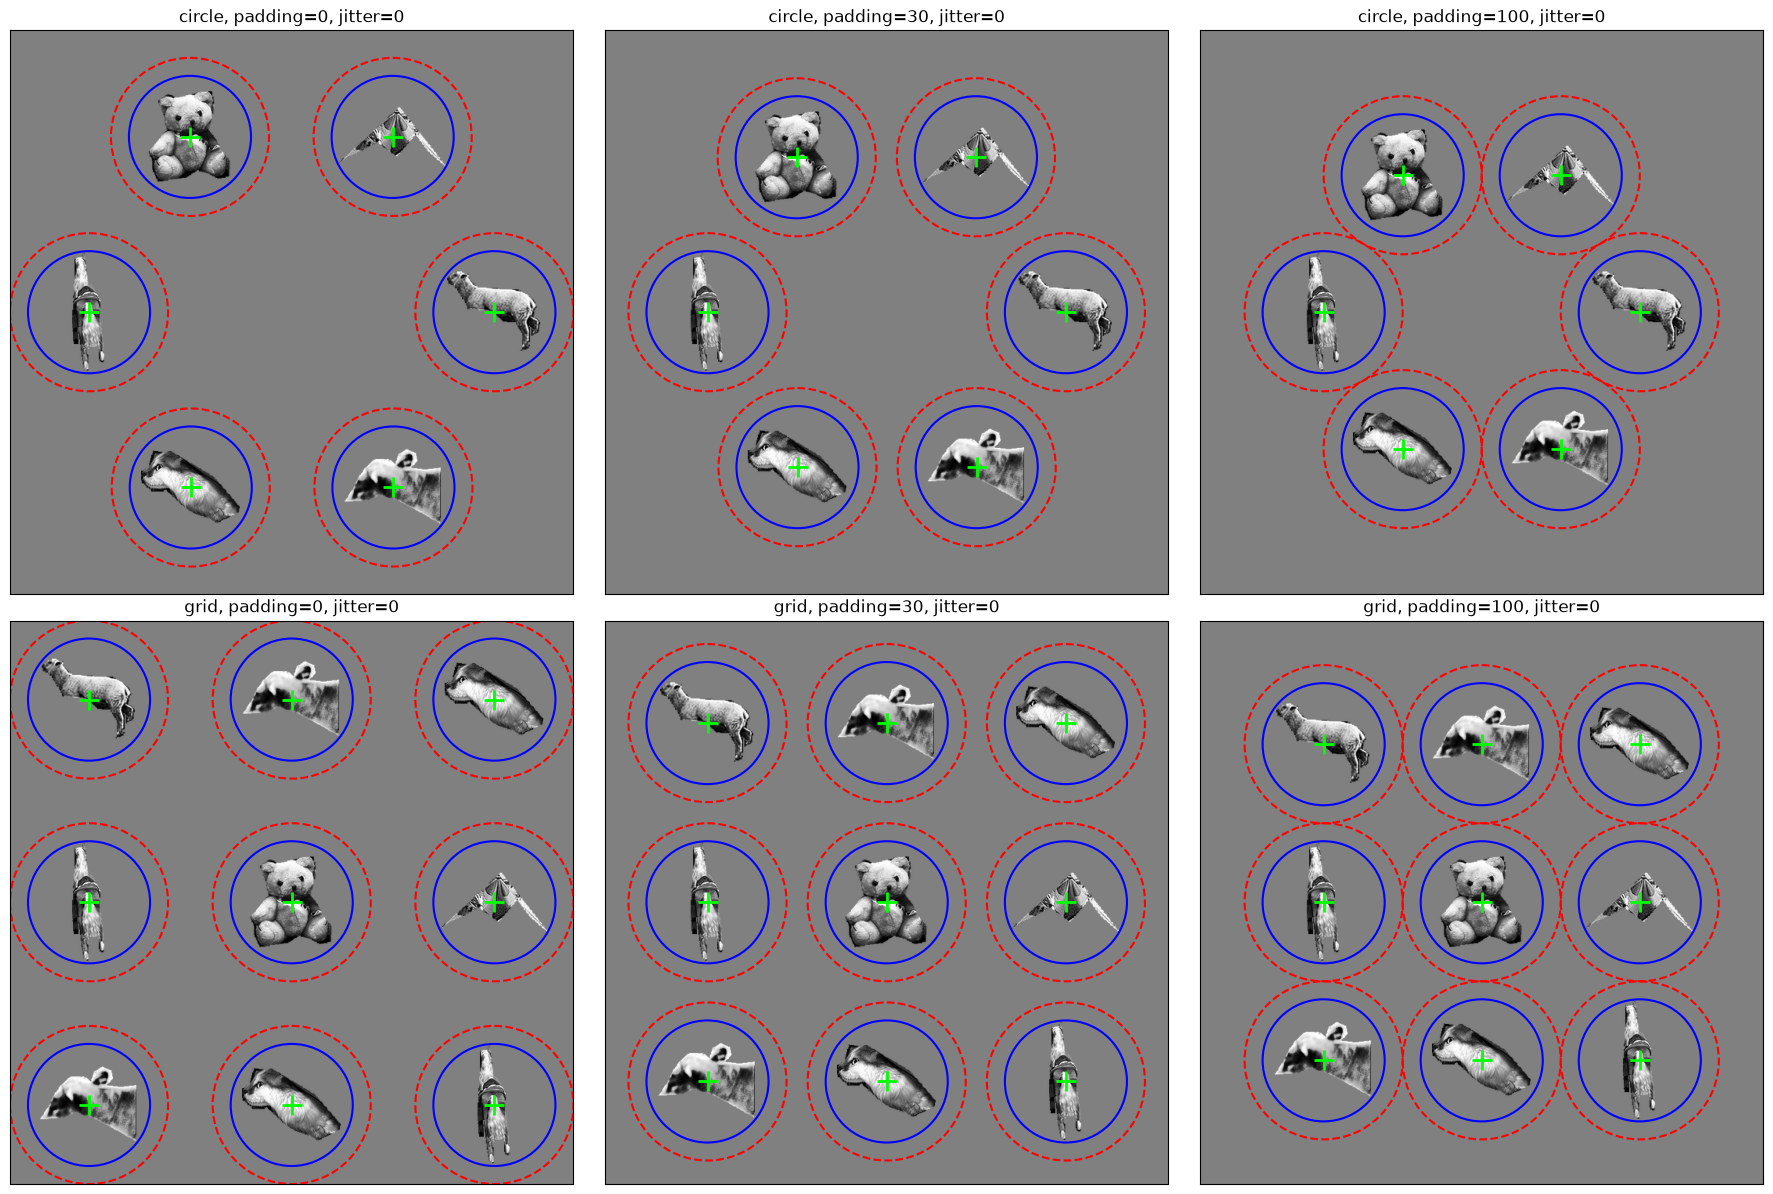

In [3]:
padding_values = [0, 30, 100]

fig, axes = plt.subplots(2, len(padding_values), figsize=(6 * len(padding_values), 12))
for col, padding in enumerate(padding_values):
    bg, pts = render_background(padding, jitter=0.0, arrangement='circle')
    draw_arrangement(axes[0, col], bg, pts)
    axes[0, col].set_title(f'circle, padding={padding}, jitter=0')

    bg, pts = render_background(padding, jitter=0.0, arrangement='grid')
    draw_arrangement(axes[1, col], bg, pts)
    axes[1, col].set_title(f'grid, padding={padding}, jitter=0')

plt.tight_layout()
plt.show()

## Cell 2: jitter (rows) x padding (columns), circle and grid arrangements

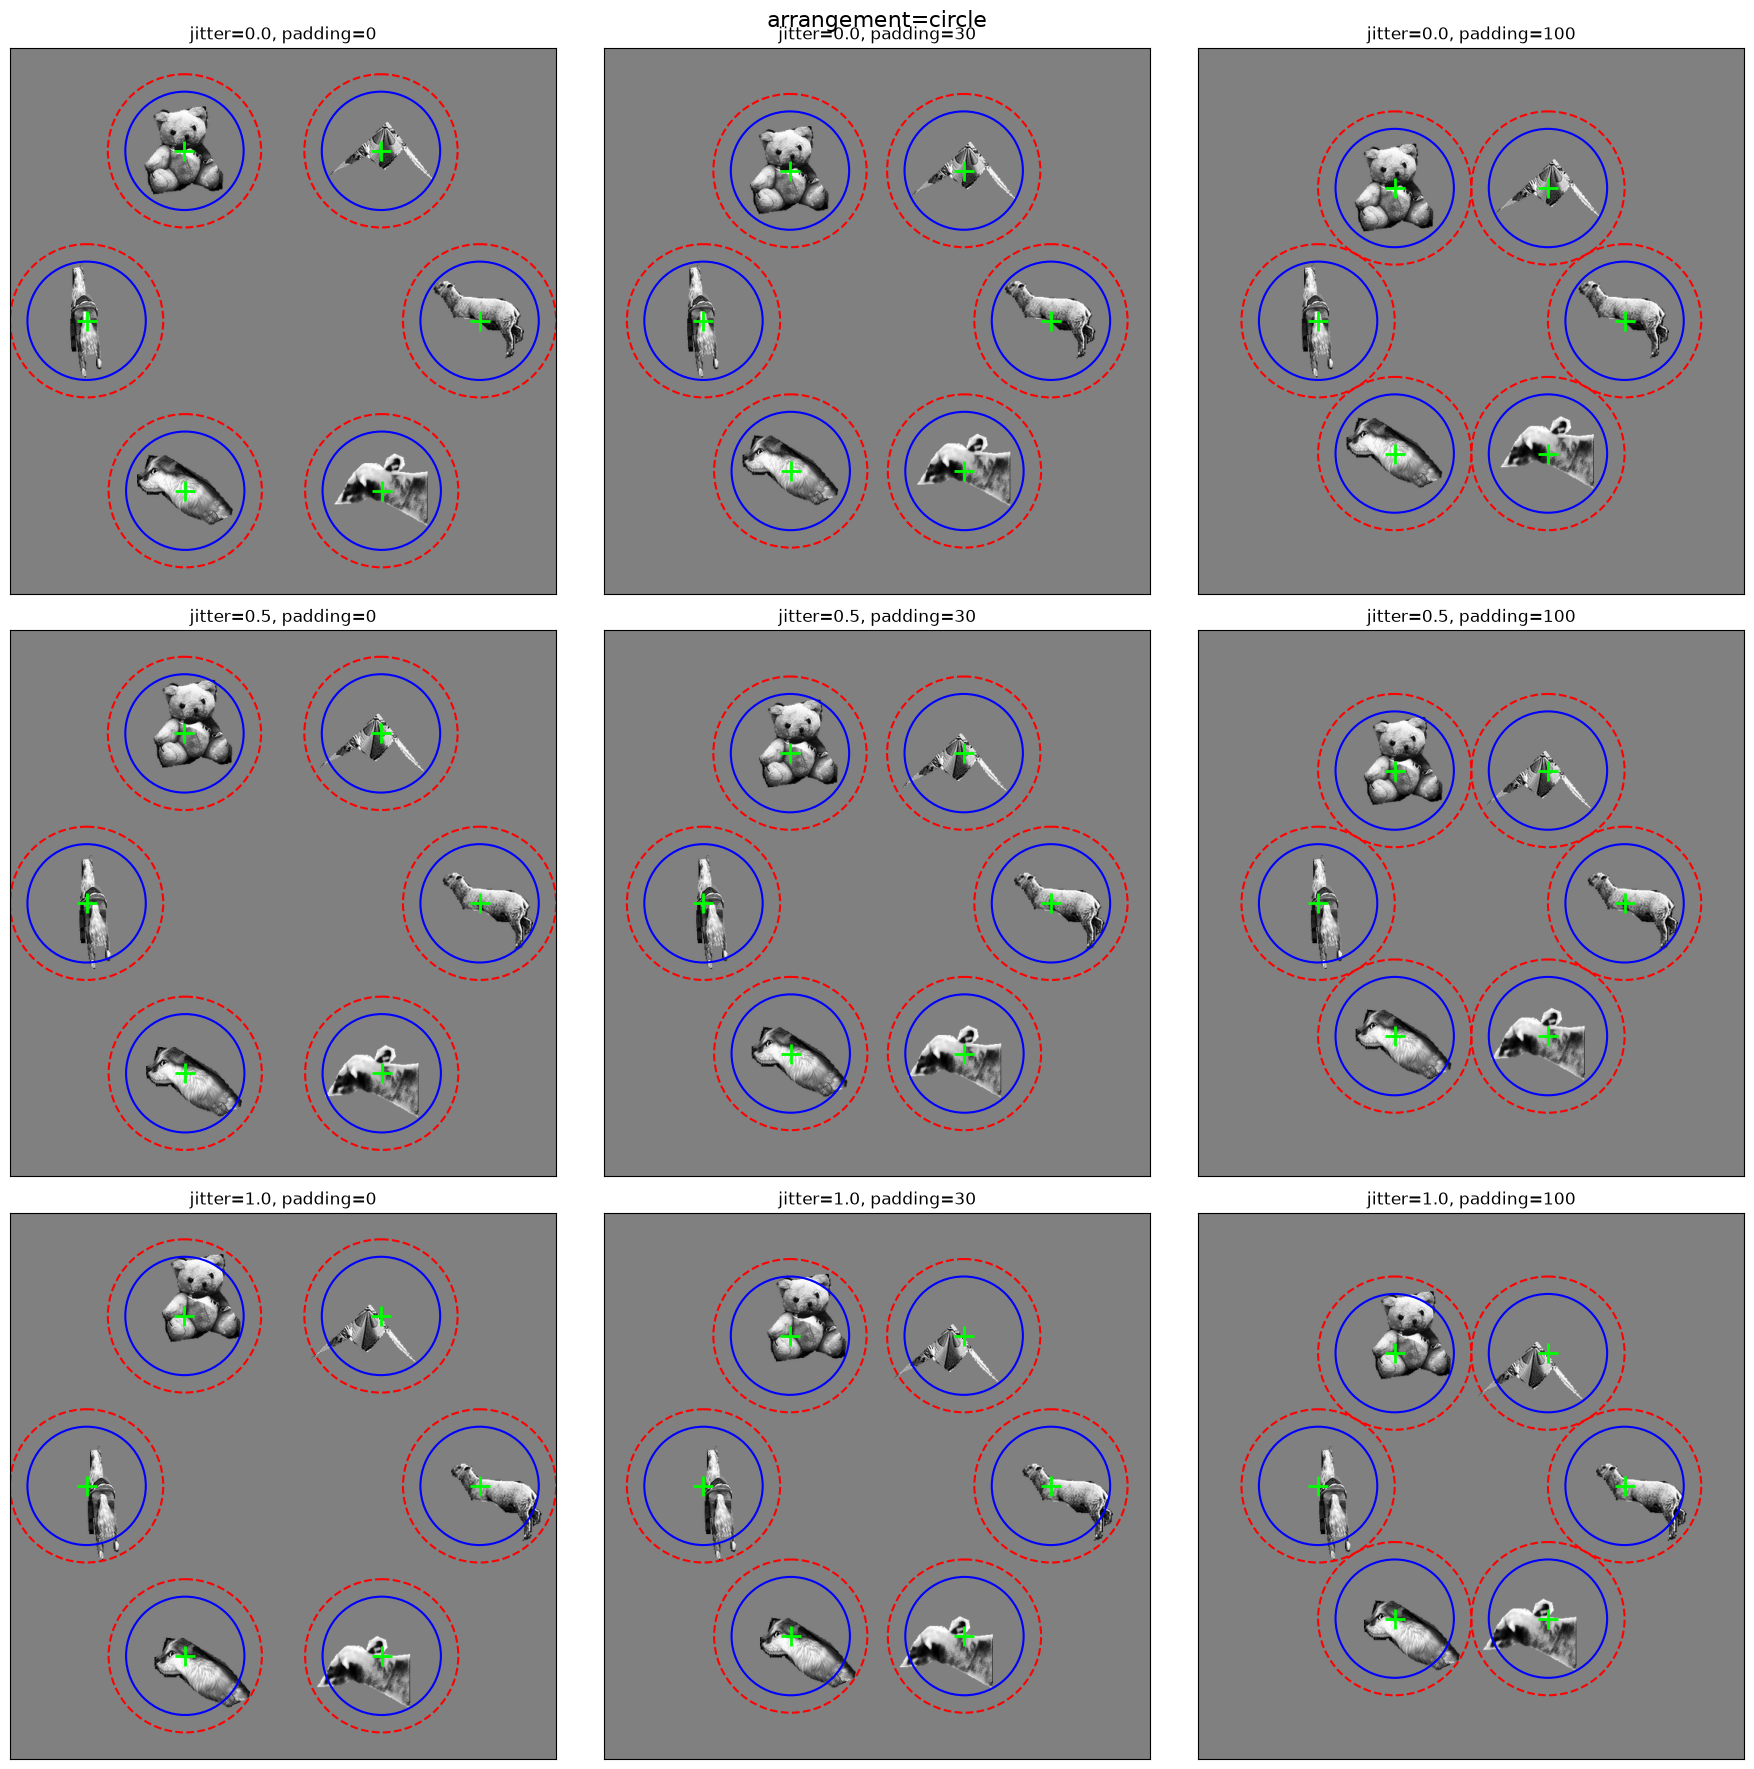

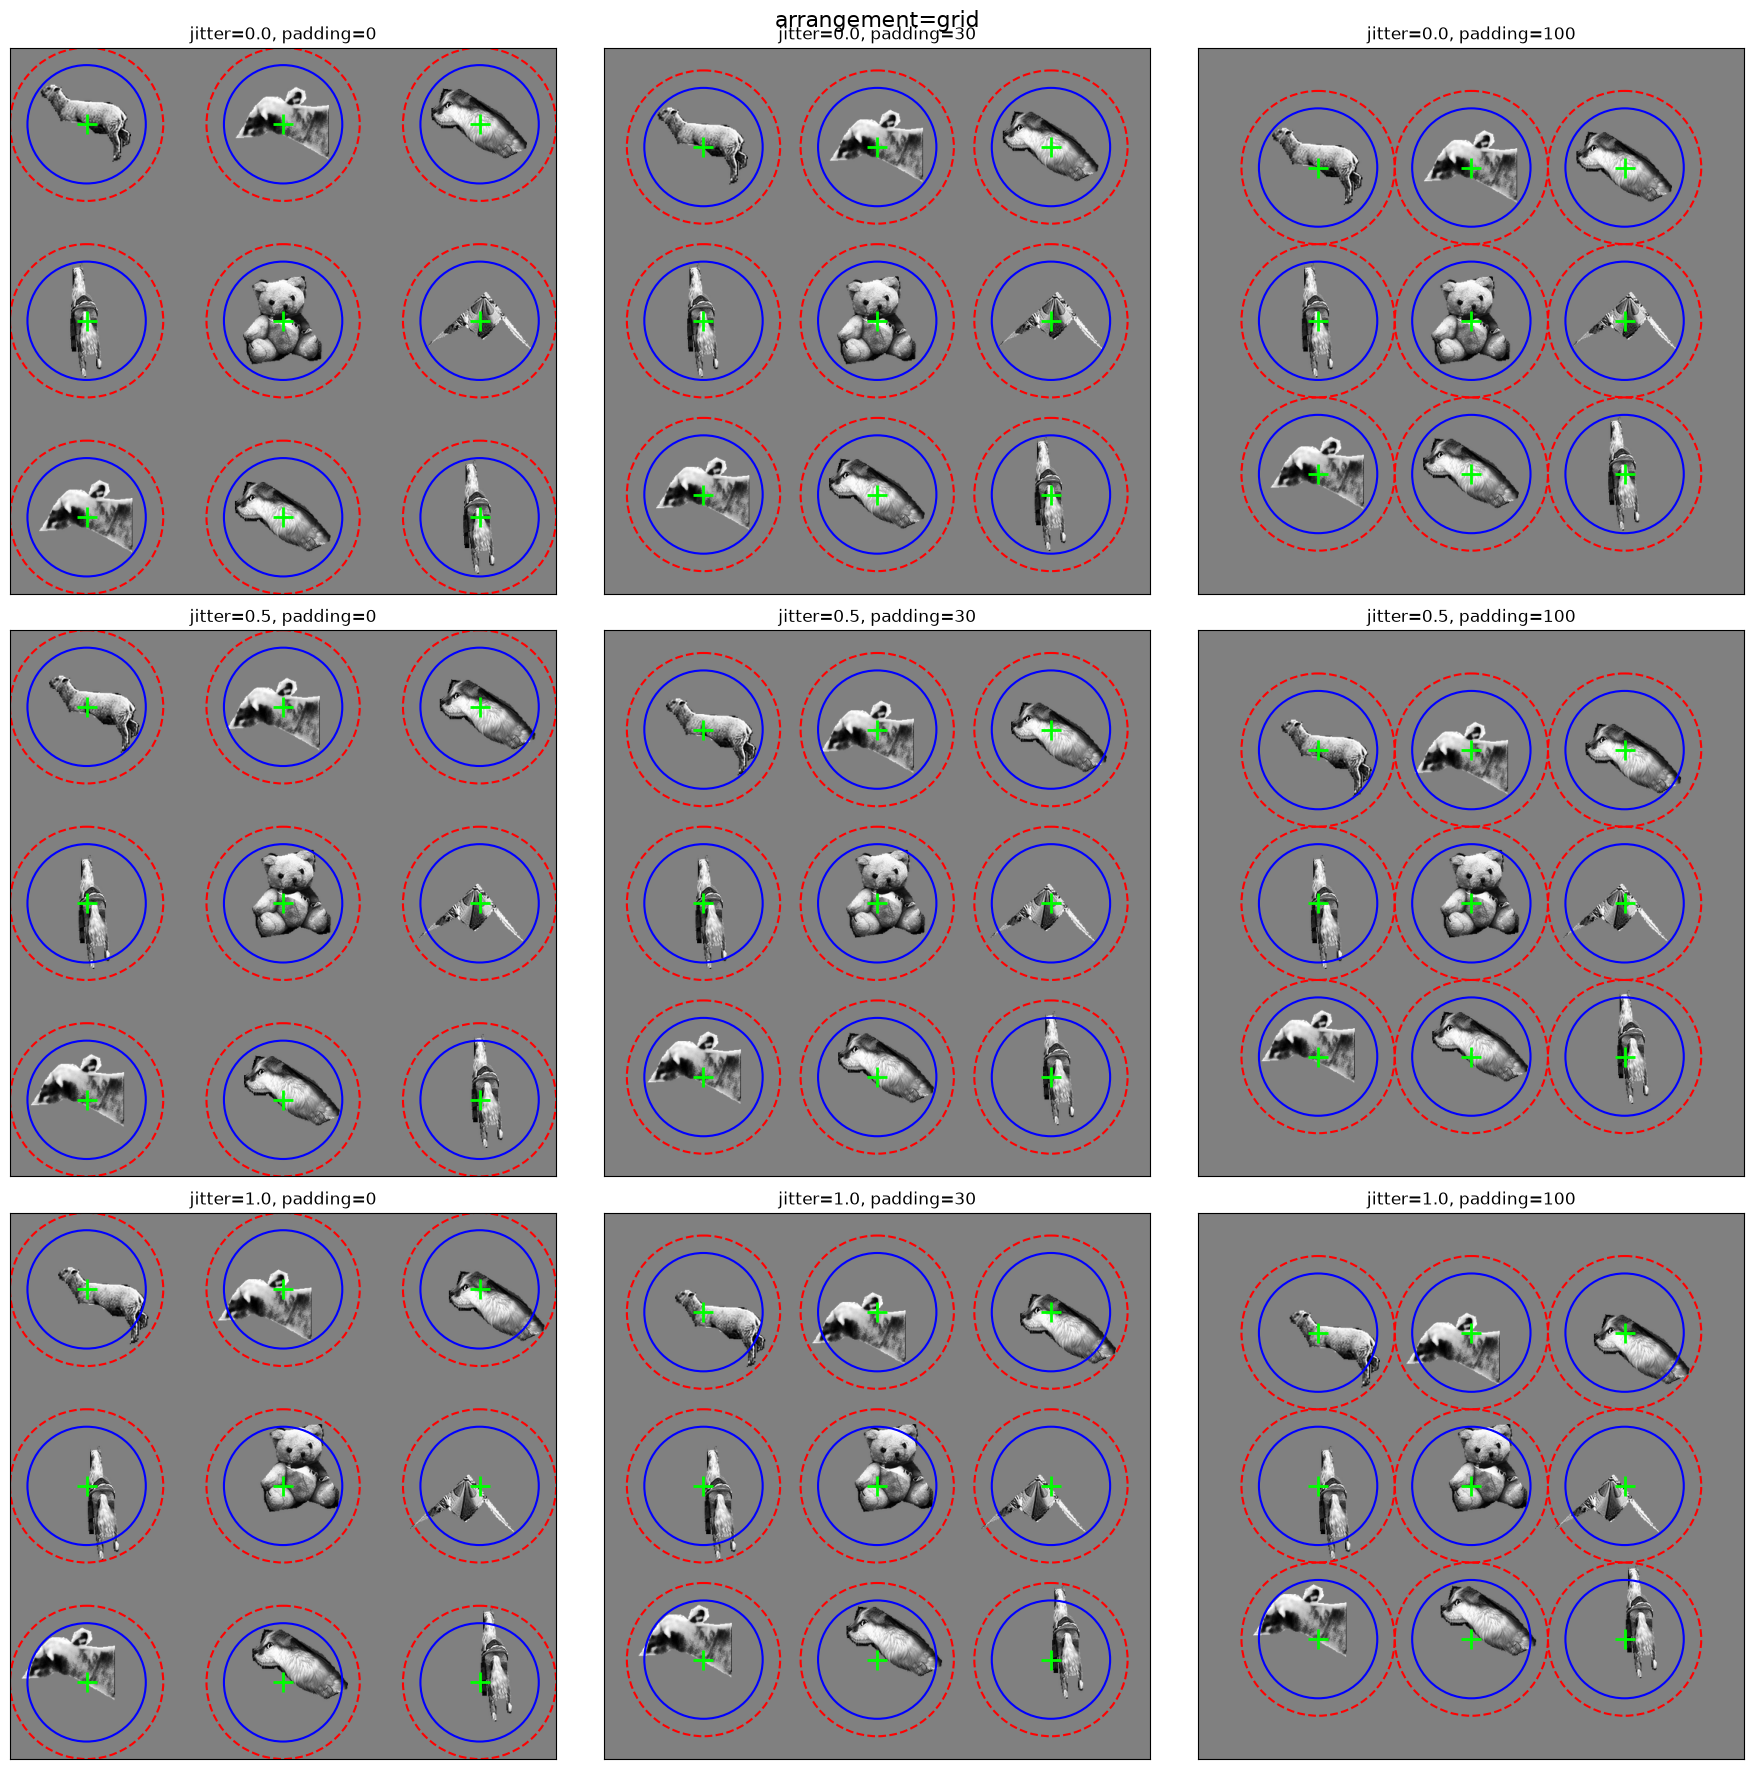

In [4]:
jitter_values = [0.0, 0.5, 1.0]
padding_values = [0, 30, 100]

for arrangement in ['circle', 'grid']:
    fig, axes = plt.subplots(len(jitter_values), len(padding_values), figsize=(6 * len(padding_values), 6 * len(jitter_values)))
    for row, jitter in enumerate(jitter_values):
        for col, padding in enumerate(padding_values):
            bg, pts = render_background(padding, jitter, arrangement=arrangement, seed=0)
            draw_arrangement(axes[row, col], bg, pts)
            axes[row, col].set_title(f'jitter={jitter}, padding={padding}')
    fig.suptitle(f'arrangement={arrangement}', fontsize=16)
    plt.tight_layout()
    plt.show()

## Cell 3: circle arrangement, padding=30, scale (rows) x jitter (columns)

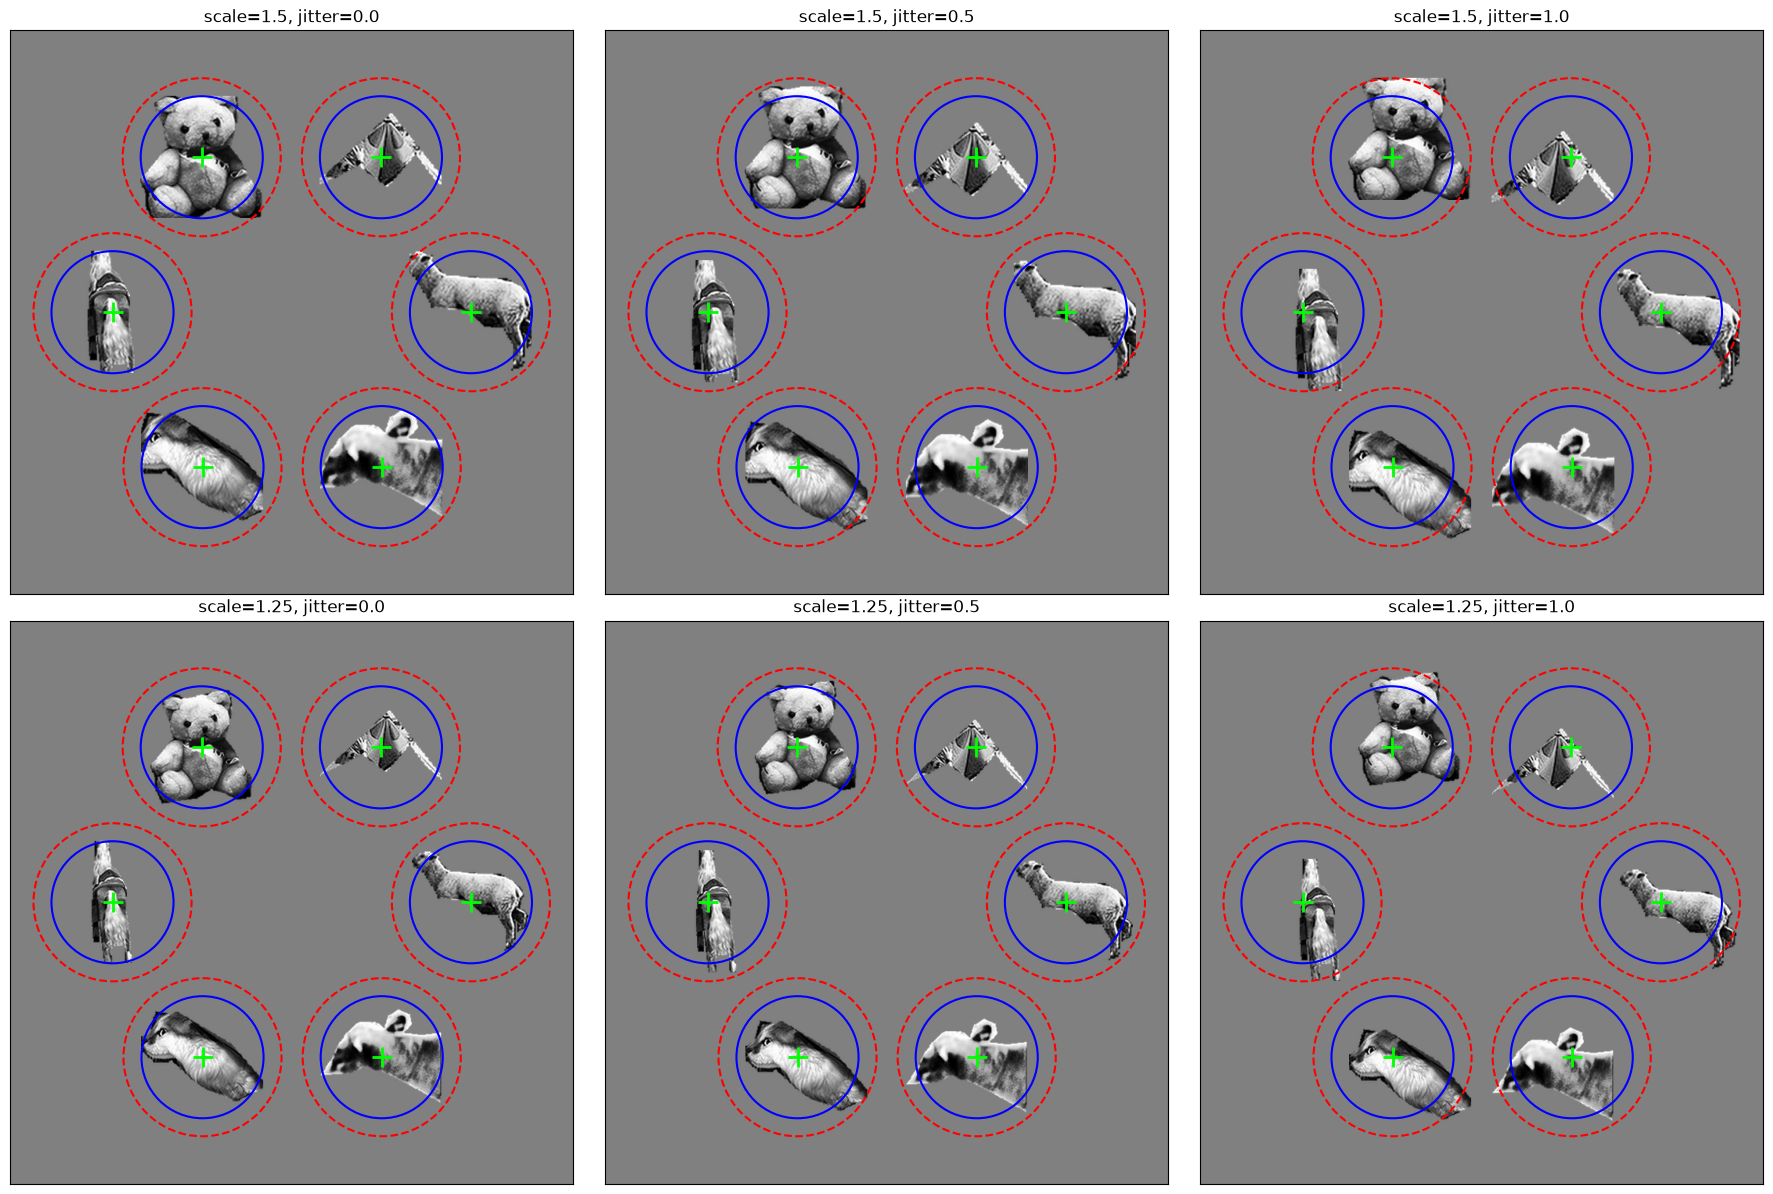

In [5]:
scale_values = [1.5, 1.25]
jitter_values = [0.0, 0.5, 1.0]
padding = 30

fig, axes = plt.subplots(len(scale_values), len(jitter_values), figsize=(6 * len(jitter_values), 6 * len(scale_values)))
for row, scale in enumerate(scale_values):
    for col, jitter in enumerate(jitter_values):
        bg, pts = render_background(padding, jitter, arrangement='circle', scale=scale, seed=0)
        draw_arrangement(axes[row, col], bg, pts)
        axes[row, col].set_title(f'scale={scale}, jitter={jitter}')

plt.tight_layout()
plt.show()